### LeNet 5 Pytorch Implementation

Research Paper Link :- https://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf

![LeNet5 Architecture](https://upload.wikimedia.org/wikipedia/commons/3/35/LeNet-5_architecture.svg)


In [ ]:
!pip3 install torch torchvision

### Importing Libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### Defining LeNet 5 Architecture

##### 📌 LeNet-5 Output Size Calculations (Input = 28×28)

We use the standard formula for convolution/pooling:

$$
\text{Output size} = \frac{W - K + 2P}{S} + 1
$$

Where:  
- \( W \): input width/height  
- \( K \): kernel (filter) size  
- \( P \): padding  
- \( S \): stride  

---

🔹 Step-by-step Calculations

Step 1: Conv1
**Layer:** `nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)`

$$
\frac{28 - 5 + 2 \cdot 2}{1} + 1 = \frac{27}{1} + 1 = 28
$$  

**Output:** 6 × 28 × 28

---

 Step 2: Pool1
**Layer:** `nn.AvgPool2d(kernel_size=2, stride=2)`

$$
\frac{28 - 2}{2} + 1 = \frac{26}{2} + 1 = 13 + 1 = 14
$$  

**Output:** 6 × 14 × 14

---

 Step 3: Conv2
**Layer:** `nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)`

$$
\frac{14 - 5 + 0}{1} + 1 = 9 + 1 = 10
$$  

**Output:** 16 × 10 × 10

---

Step 4: Pool2
**Layer:** `nn.AvgPool2d(kernel_size=2, stride=2)`

$$
\frac{10 - 2}{2} + 1 = \frac{8}{2} + 1 = 4 + 1 = 5
$$  

**Output:** 16 × 5 × 5

---

 Step 5: Flatten
$$
16 \times 5 \times 5 = 400
$$  

**Output:** 400 features

---

 Step 6: Fully Connected Layers
- **FC1:** 400 → 120  
- **FC2:** 120 → 84  
- **FC3:** 84 → 10 (classes)

---

 ✅ Final Shape Progression

| Layer | Calculation | Output Size |
|-------|-------------|-------------|
| Input | – | 1 × 28 × 28 |
| Conv1 | $$ (28-5+4)/1+1 = 28 $$ | 6 × 28 × 28 |
| Pool1 | $$ (28-2)/2+1 = 14 $$ | 6 × 14 × 14 |
| Conv2 | $$ (14-5)/1+1 = 10 $$ | 16 × 10 × 10 |
| Pool2 | $$ (10-2)/2+1 = 5 $$ | 16 × 5 × 5 |
| Flatten | $$ 16 \cdot 5 \cdot 5 = 400 $$ | 400 |
| FC1 | – | 120 |
| FC2 | – | 84 |
| FC3 | – | 10 |



In [4]:
class LeNet5(nn.Module):
   def __init__(self):
      super(LeNet5,self).__init__()
      self.conv1 = nn.Conv2d(1,6,kernel_size=5,stride=1,padding=2)
      self.relu = nn.ReLU()
      self.pool = nn.AvgPool2d(kernel_size=2,stride=2)
      self.conv2 = nn.Conv2d(6,16,kernel_size=5,stride=1)
      self.fc1= nn.Linear(16*5*5,120)
      self.fc2 = nn.Linear(120,84)
      self.fc3 = nn.Linear(84,10)
      
   def forward(self,x):
      x = self.pool(self.relu(self.conv1(x)))
      x = self.pool(self.relu(self.conv2(x)))
      x = x.view(-1,16*5*5)
      x = self.relu(self.fc1(x))
      x = self.relu(self.fc2(x))
      x = self.fc3(x)
      return x

### Hyperparameters

In [5]:
batch_size = 64
epochs = 10
learning_rate = 0.001

### Data Loading and Transformation

In [7]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)
train_dataset = torchvision.datasets.MNIST(
    root="../../data/MNIST", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="../../data/MNIST", train=False, transform=transform, download=True
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model, Loss, and Optimizer

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### Model Training & Evaluation

In [8]:
# Training Loop
train_losses, test_accuracies = [], []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f"Accuracy on test set: {accuracy:.2f}%")

Epoch [1/10], Loss: 0.2628
Accuracy on test set: 97.41%
Epoch [2/10], Loss: 0.0763
Accuracy on test set: 98.24%
Epoch [3/10], Loss: 0.0540
Accuracy on test set: 98.30%
Epoch [4/10], Loss: 0.0426
Accuracy on test set: 98.75%
Epoch [5/10], Loss: 0.0353
Accuracy on test set: 98.91%
Epoch [6/10], Loss: 0.0293
Accuracy on test set: 98.92%
Epoch [7/10], Loss: 0.0251
Accuracy on test set: 98.47%
Epoch [8/10], Loss: 0.0228
Accuracy on test set: 98.96%
Epoch [9/10], Loss: 0.0193
Accuracy on test set: 99.09%
Epoch [10/10], Loss: 0.0181
Accuracy on test set: 98.88%


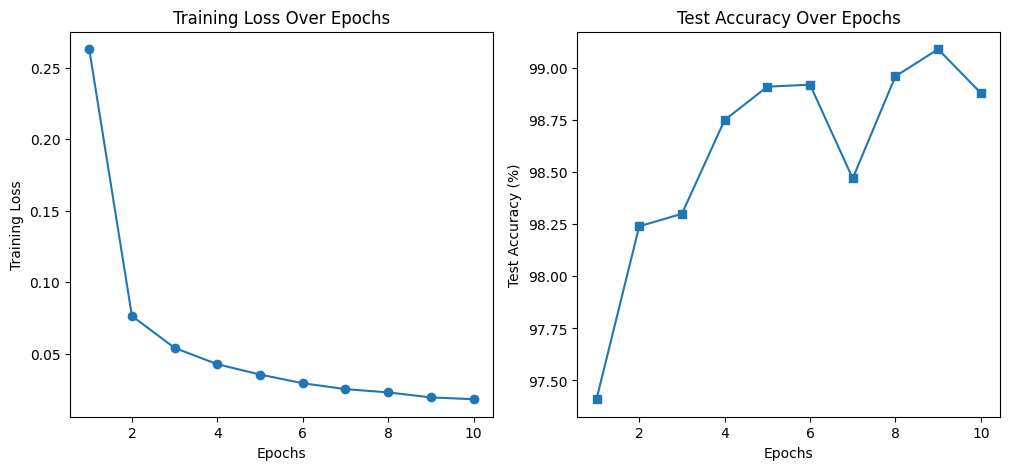

In [9]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker="o", linestyle="-")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), test_accuracies, marker="s", linestyle="-")
plt.xlabel("Epochs")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Over Epochs")
plt.show()

In [10]:
# Inference Function
def predict_image(image):
    model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0)  # Add batch dimension
        output = model(image)
        _, predicted = torch.max(output, 1)
    return predicted.item()

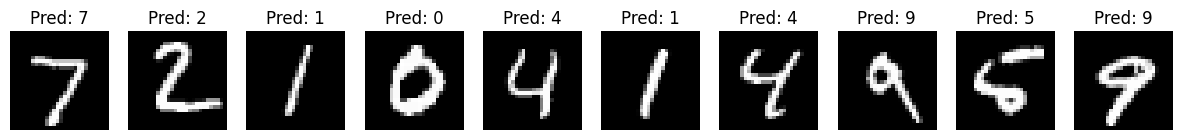

In [11]:
# Visualizing Predictions
samples, labels = next(iter(test_loader))
samples, labels = samples.to(device), labels.to(device)
predictions = [predict_image(img) for img in samples[:10]]

fig, axes = plt.subplots(1, 10, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}")
    ax.axis("off")
plt.show()